# Análisis de Accidentes: Madrid 2025
## Predicción de Gravedad, Detección de Infracciones y Zonas de Riesgo
**Asignatura:** Inteligencia Artificial
**Autor:** Lino Vives Colón

---

# 1. Introducción
La seguridad vial es un problema que requiere distintos enfoques. Este proyecto utiliza el dataset de Accidentes de Tráfico del Ayuntamiento de Madrid (2025) para abordar el problema desde tres perspectivas distintas mediante técnicas de ML:

1.  **Gestión de emergencias:** Predecir la gravedad de un accidente para optimizar la respuesta sanitaria.
2.  **Prevención de riesgos:** Identificar los patrones asociados al consumo de alcohol para mejorar los controles policiales.
3.  **Infraestructura:** Detectar "puntos negros" en la ciudad mediante clustering.

---

### 1.1 Objetivos del Proyecto
El trabajo se estructura en tres bloques principales:

#### A) Modelo de severidad
* **Objetivo:** Determinar la probabilidad de que un accidente resulte en hospitalización o fallecimiento.
* **Target:** `lesividad` (grave vs leve).
* **Utilidad:** Priorizar de recursos de emergencia.

#### B) Modelo de perfil de riesgo
* **Objetivo:** Predecir la probabilidad de un positivo en alcoholemia basándose en factores como la hora, zona, o el perfil del conductor.
* **Target:** `positiva_alcohol`.
* **Utilidad:** Optimización de controles de policía.

#### C) Detección de puntos negros
* **Objetivo:** Agrupar accidentes espacialmente para descubrir zonas de alta concentración de accidentes.
* **Técnica:** K-Means clustering.
* **Utilidad:** Identificación de cruces o calles que requieren intervención.

---

### 1.2 Descripción del Dataset
Analizaré más de 41.000 registros de accidentes ocurridos en Madrid durante el año 2025.
* **Dimensiones:** Ubicación (coordenadas UTM), tiempo (Fecha/Hora), meteorología, datos del conductor (edad, sexo) y tipo de vehículo.
* **Limpieza:** Haré una limpieza de coordenadas nulas y una transformación de variables categóricas a numéricas (feature engineering) para entrenar los modelos de IA.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

# Configuración visual para los gráficos
plt.style.use('ggplot')
pd.set_option('display.max_columns', None) # Para ver todas las columnas en pantalla

ruta_archivo = '/kaggle/input/accidentalidad-madrid-2025/2025_Accidentalidad.csv'

# Carga del CSV
try:
    df = pd.read_csv(ruta_archivo, sep=';')
    print("Librerías importadas y dataset cargado")
    print(f"Dimensiones del dataset: {df.shape[0]} accidentes registrados, {df.shape[1]} variables.")
    
    print("\nVista previa de los datos:")
    display(df.head(5))
    
except FileNotFoundError:
    print("ERROR: No se encuentra el archivo.")

Librerías importadas y dataset cargado
Dimensiones del dataset: 41730 accidentes registrados, 19 variables.

Vista previa de los datos:


,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
0,2025S000056,01/01/2025,0:49:00,CALL. LOPEZ DE HOYOS / CALL. ROS DE OLANO,140,5,CHAMARTÍN,Colisión fronto-lateral,Despejado,Ciclomotor,Conductor,De 30 a 34 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,442966.0,4477385.0,N,NaN
1,2025S000056,01/01/2025,0:49:00,CALL. LOPEZ DE HOYOS / CALL. ROS DE OLANO,140,5,CHAMARTÍN,Colisión fronto-lateral,Despejado,Turismo,Conductor,De 40 a 44 años,Hombre,14.0,Sin asistencia sanitaria,442966.0,4477385.0,N,NaN
2,2025S000056,01/01/2025,0:49:00,CALL. LOPEZ DE HOYOS / CALL. ROS DE OLANO,140,5,CHAMARTÍN,Colisión fronto-lateral,Despejado,Turismo,Pasajero,De 40 a 44 años,Mujer,14.0,Sin asistencia sanitaria,442966.0,4477385.0,N,NaN
3,2025S000057,01/01/2025,2:20:00,GTA. RIO ZANCARA / CALL. ARROYO DE POZUELO,1,9,MONCLOA-ARAVACA,Colisión lateral,Despejado,Turismo,Conductor,De 21 a 24 años,Hombre,NaN,NaN,433911.0,4478290.0,N,NaN
4,2025S000057,01/01/2025,2:20:00,GTA. RIO ZANCARA / CALL. ARROYO DE POZUELO,1,9,MONCLOA-ARAVACA,Colisión lateral,Despejado,Turismo,Conductor,De 45 a 49 años,Hombre,NaN,NaN,433911.0,4478290.0,N,NaN


# 2. Preprocesamiento y Limpieza de Datos
Una vez cargados los datos, es necesario realizar una transformación (**feature engineering**) para que los algoritmos puedan interpretarlos correctamente.

En esta fase realizaré:
1. **Limpieza:** Eliminación de los pocos registros que no tienen coordenadas, ya que son inservibles para el análisis espacial.
2. **Creación de Variables Objetivo (Targets):**
   * **`es_grave`**: Convertiré la columna de texto `lesividad` en una variable binaria (0/1). Se considera 1 (grave) si hubo ingreso hospitalario o fallecimiento.
   * **`target_alcohol`**: Convertiré la columna `positiva_alcohol` en binaria (1 si dio positivo, 0 si no).
3. **Transformación Numérica:**:
   * **Sexo:** a 0 y 1.
   * **Hora:** a número entero (0-23).
   * **Fecha:** si es fin de semana (viernes-domingo), importante para el modelo de alcoholemia.

---

In [2]:
# Limpieza
# Elimino las filas que no tienen coordenadas (son irrelevantes para el mapa y muy pocas)
df_clean = df.dropna(subset=['coordenada_x_utm', 'coordenada_y_utm']).copy()

# Creación de variables objetivo (TARGETS)

#Target 1: GRAVEDAD 
#"Grave" (1) si hubo ingreso hospitalario o fallecimiento. Leve (0) el resto.
def definir_gravedad(estado):
    graves = [
        'Ingreso inferior o igual a 24 horas', 
        'Ingreso superior a 24 horas', 
        'Fallecido 24 horas'
    ]
    if pd.isna(estado): return 0
    return 1 if estado in graves else 0

df_clean['es_grave'] = df_clean['lesividad'].apply(definir_gravedad)

# Target 2: ALCOHOL
# 1 = Positivo ('S'), 0 = Negativo ('N')
df_clean['target_alcohol'] = df_clean['positiva_alcohol'].fillna('N').map({'S': 1, 'N': 0})

# Transformación de variables

# 1. Sexo: Hombre=1, Mujer=0
# Filtramos primero para quitar desconocido
df_clean = df_clean[df_clean['sexo'].isin(['Hombre', 'Mujer'])]
df_clean['sexo_num'] = df_clean['sexo'].map({'Hombre': 1, 'Mujer': 0})

# 2. Hora: hora exatca (hh:mm:ss) a uníco numero hh
df_clean['hora_num'] = pd.to_datetime(df_clean['hora'], format='%H:%M:%S').dt.hour

# 3. Fin de semana
df_clean['fecha_dt'] = pd.to_datetime(df_clean['fecha'], format='%d/%m/%Y')
df_clean['es_finde'] = (df_clean['fecha_dt'].dt.dayofweek >= 5).astype(int)

print("Datos procesados correctamente.")
print(f"Filas finales para entrenar: {df_clean.shape[0]}")
print("\nEjemplo de las nuevas variables numéricas:")
print(df_clean[['hora_num', 'sexo_num', 'es_finde', 'es_grave', 'target_alcohol']])

Datos procesados correctamente.
Filas finales para entrenar: 37306

Ejemplo de las nuevas variables numéricas:
       hora_num  sexo_num  es_finde  es_grave  target_alcohol
0             0         1         0         0               0
1             0         1         0         0               0
2             0         0         0         0               0
3             2         1         0         0               0
4             2         1         0         0               0
...         ...       ...       ...       ...             ...
41725        21         0         0         0               0
41726        21         1         0         0               0
41727        20         1         0         1               0
41728        19         1         0         0               0
41729        19         1         0         0               0

[37306 rows x 5 columns]


# 3. Análisis Exploratorio de Datos (EDA)

### Ver los datos antes de modelar
Una vez limpiado y estructurad el dataset, pasamos a la fase de inspección visual. El objetivo no es solo hacer gráficos estéticos, sino responder a preguntas y detectar posibles dificultades para el algoritmo de ML.

En esta parte, generaré cuatro gráficos para validar las siguientes hipótesis:

1.  **El desbalance:** ¿Cómo de severa es la desproporción entre accidentes leves y graves?
2.  **Horario:** ¿Existe una hora con más accidentes? Para ver si la distribución de accidentes graves difiere de los leves a lo largo del día.
3.  **Alcohol:** Más allá de la cantidad de accidentes, ¿aumenta la probabilidad de muerte o heridos graves si hay alcohol involucrado?
4.  **Matriz de correlación:** ¿Existe alguna variable que por sí sola nos diga si un accidente será grave?

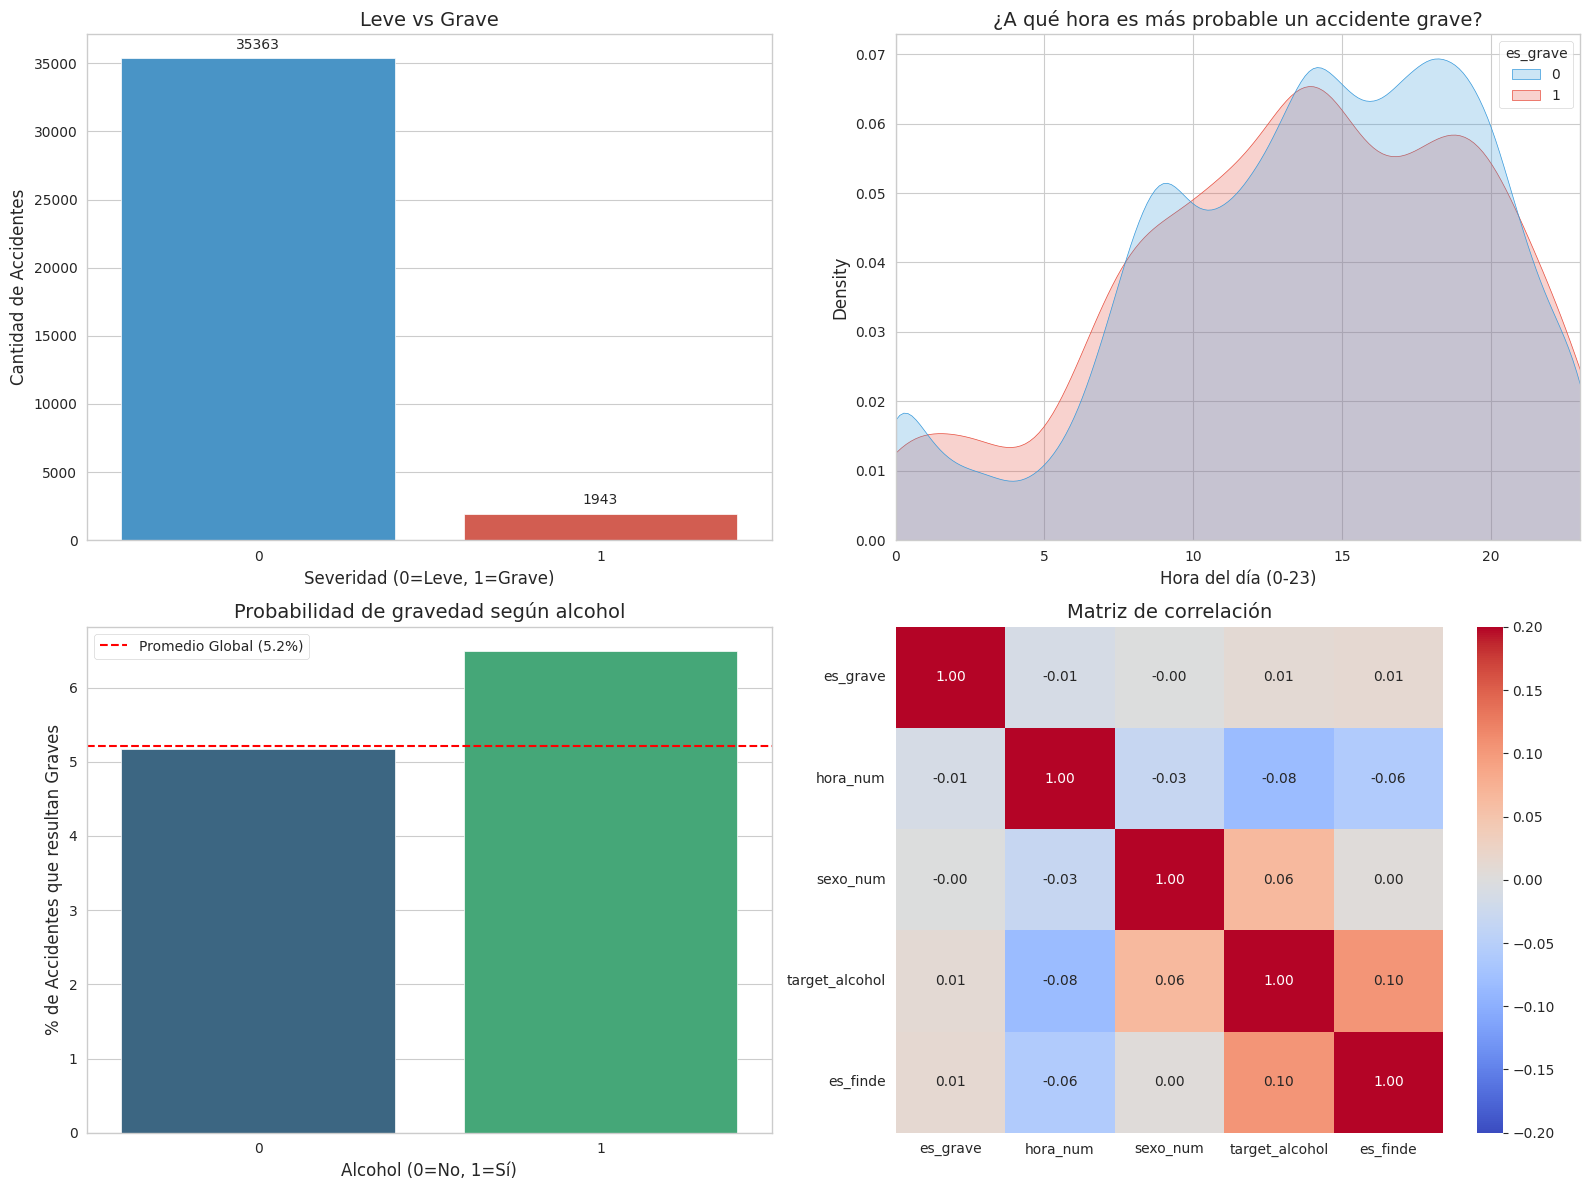

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

palette_gravedad = {0: '#3498db', 1: '#e74c3c', '0': '#3498db', '1': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Desbalance
sns.countplot(x='es_grave', hue='es_grave', legend=False, data=df_clean, palette=palette_gravedad, ax=axes[0, 0])
axes[0, 0].set_title('Leve vs Grave', fontsize=14)
axes[0, 0].set_xlabel('Severidad (0=Leve, 1=Grave)')
axes[0, 0].set_ylabel('Cantidad de Accidentes')

for p in axes[0, 0].patches:
    height = int(p.get_height())
    if height > 0: 
        axes[0, 0].annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# Gráfico 2: Accidentes según horas
sns.kdeplot(data=df_clean, x='hora_num', hue='es_grave', palette=palette_gravedad, fill=True, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title('¿A qué hora es más probable un accidente grave?', fontsize=14)
axes[0, 1].set_xlabel('Hora del día (0-23)')
axes[0, 1].set_xlim(0, 23)


# Gráfico 3: El factor alcohol
alcohol_impact = df_clean.groupby('target_alcohol')['es_grave'].mean().reset_index()
alcohol_impact['es_grave'] = alcohol_impact['es_grave'] * 100 

sns.barplot(x='target_alcohol', y='es_grave', hue='target_alcohol', legend=False, data=alcohol_impact, palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Probabilidad de gravedad según alcohol', fontsize=14)
axes[1, 0].set_xlabel('Alcohol (0=No, 1=Sí)')
axes[1, 0].set_ylabel('% de Accidentes que resultan Graves')
promedio_global = df_clean['es_grave'].astype(float).mean() * 100
axes[1, 0].axhline(y=promedio_global, color='r', linestyle='--', label=f'Promedio Global ({promedio_global:.1f}%)')
axes[1, 0].legend()


# Gráfico 4: Correlaciones
cols_corr = ['es_grave', 'hora_num', 'sexo_num', 'target_alcohol', 'es_finde']
corr_matrix = df_clean[cols_corr].astype(float).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-0.2, vmax=0.2, ax=axes[1, 1])
axes[1, 1].set_title('Matriz de correlación', fontsize=14)


plt.tight_layout()
plt.show()

### 3.1. Desbalance de Clases

El gráfico de barras confirma que el dataset tiene bastante desbalance:
* **Accidentes Leves (0):** 35,363 casos (95% del total).
* **Accidentes Graves (1):** 1,943 casos (5% del total).

**Interpretación:**
Por cada accidente grave, ocurren aproximadamente 18 accidentes leves. Esto explica por qué la matriz de correlación muestra valores tan bajos: la señal de gravedad es muy débil.

**Implicación para el modelo:**
Este gráfico justifica por qué no podemos usar un modelo simple. Si entrenamos un algoritmo estándar sin ajustes, aprenderá a predecir siempre leve para acertar el 95% de las veces, ignorando por completo los casos graves (que son los que nos importa detectar). Esto nos da la necesidad de usar métricas como el recall y técnicas de ponderación de clases como scale_pos_weight en la siguiente fase.

### 3.2. Distribución temporal

El gráfico de densidad revela dos momentos diferentes según la hora del día:
1.  **Horas Punta (14:00 y 19:00):** Coinciden con los picos de tráfico laboral. Aquí ocurren la mayoría de los accidentes, pero la curva azul está ligeramente por encima de la roja.

2.  **La Madrugada (00:00 - 06:00):** Aquí vemos que en el área entre las 0 y las 5 de la mañana la curva roja no baja tanto como la azul. Por lo que en estas horas los accidentes graves superan a los leves.

**Interpretación:**
Aunque hay menos accidentes por la noche, la proporcionalidad de gravedad es mayor.
Un accidente a las 4:00 AM tiene muchas más probabilidades de ser grave que uno a las 14:00 PM. Esto sugiere que factores nocturnos (velocidad por carreteras vacías, fatiga o visibilidad reducida) son factores de la gravedad, dando importancia a la variable `hora_num` para el modelo.

### 3.3. El alcohol

El gráfico de barras compara la probabilidad de que un accidente sea grave en función de si hubo alcohol o no.
* **Línea roja (promedio):** La tasa base de gravedad es del 5.2%.
* **Sin alcohol (barra azul):** El riesgo se mantiene ligeramente por debajo del promedio.
* **Con alcohol (barra verde):** El riesgo sube a 6.5%.

**Interpretación:**
Aunque pueda parecer una diferencia pequeña (del 5% al 6.5%), implica que el alcohol aumenta el riesgo de gravedad en casi un 25%. Esto confirma que la variable `target_alcohol` aporta información al modelo, diferenciando comportamientos de riesgo frente a otros accidentes.

### 3.4. Análisis de correlación

La matriz muestra valores muy bajos entre nuestra variable objetivo (`es_grave`) y el resto de predictores. 

**Interpretación:**
Este resultado es la prueba de que el problema no es lineal.
No existe una regla simple, tipo si aumenta X, aumenta la gravedad. La gravedad es el resultado de una combinación compleja de factores (ej: Alcohol + Madrugada + Fin de Semana) que una correlación no puede detectar.

**Conclusión del EDA:**
1.  **Desbalance muy alto:** Pocos casos graves entre muchos leves.
2.  **Señales débiles:** Las variables individuales (como la hora o el alcohol) aportan pistas, pero ninguna es determinante por sí sola.
3.  **No lineal:** Las relaciones son complejas.

**Decisión de Modelado:**
No usaré modelos lineales simples. Usaré **XGBoost**, un algoritmo basado en árboles de decisión capaz de capturar estas relaciones no lineales y combinaciones de variables que hemos visto en los gráficos.

---

# 4. Modelo A: Detección de Accidentes Graves

### 4.1. Definición del Problema
El objetivo de esta sección es entrenar un algoritmo de ML capaz de clasificar los accidentes en dos categorías según su severidad:
* **Clase 0 (Leve):** La gran mayoría de los casos.
* **Clase 1 (Grave):** Accidentes con heridos hospitalizados o fallecidos.

### 4.2. Desbalance de Clases
El EDA reveló un desbalance alto en los datos: los accidentes graves representan menos del 5% del total.
Esto presenta una dificultad: un modelo "perezoso" podría obtener un 95% de accuracy simplemente prediciendo que todos los accidentes son leves, pero fallaría completamente en detectar los casos peligrosos.

### 4.3. Estrategia
Para solucionar esto me centraré en el recall de la clase Grave.
* **Objetivo:** Maximizar la capacidad del modelo para detectar accidentes graves reales, aunque esto implique aumentar las falsas alarmas.
* **Algoritmo:** XGBoost, un algoritmo basado en árboles de decisión, aplicando técnicas de ajuste de pesos (`scale_pos_weight`).

**Variables seleccionadas:**
* `hora_num`, `es_finde` (Factores temporales)
* `coordenada_x_utm`, `coordenada_y_utm` (Ubicación)
* `target_alcohol` (Factor de riesgo conductor)
* `sexo_num` (Demografía)

Ratio de desbalance calculado: 18.20

Accuracy: 0.7414

Informe de clasificación
              precision    recall  f1-score   support

        Leve       0.96      0.76      0.85      7073
       Grave       0.08      0.35      0.12       389

    accuracy                           0.74      7462
   macro avg       0.52      0.56      0.49      7462
weighted avg       0.91      0.74      0.81      7462



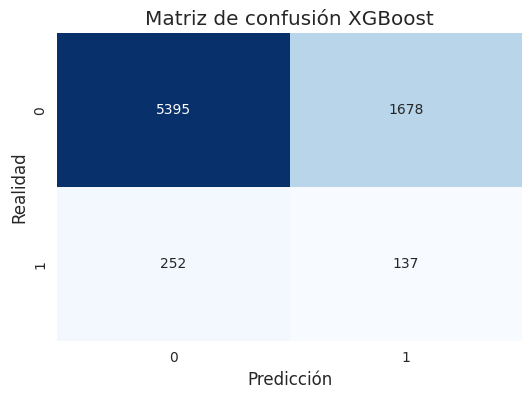

In [4]:
# XGBoost maneja el desbalance internamente con 'scale_pos_weight'
features_gravedad = ['hora_num', 'sexo_num', 'target_alcohol', 'es_finde', 'coordenada_x_utm', 'coordenada_y_utm']
X = df_clean[features_gravedad]
y = df_clean['es_grave']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calcular el ratio para el balanceo
# scale_pos_weight = (Conteo negativos) / (Conteo positivos)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de desbalance calculado: {ratio:.2f}")

# Entrenar XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,  
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train, y_train)

# Evaluación
predicciones = modelo_xgb.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, predicciones):.4f}")
print("\nInforme de clasificación")
print(classification_report(y_test, predicciones, target_names=['Leve', 'Grave']))

# Matriz
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predicciones), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusión XGBoost')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

### 4.4. Diagnóstico del modelo base: El techo del 35%

**Resultados obtenidos:**
El modelo XGBoost, configurado con pesos balanceados (`scale_pos_weight`), ha identificado el 35% de los accidentes graves (recall = 0.35).

**Benchmark:**
Para descartar que este resultado fuera una limitación del algoritmo elegido, realicé pruebas adicionales con otros modelos:
* **Random Forest:** Estancado en recall 0.33 - 0.35.
* **Balanced Bagging Classifier:** Estancado en recall 0.35.

**Interpretación:**
El hecho de que tres algoritmos distintss (Boosting, Bagging y Forest) converjan en el mismo rendimiento, confirma que hay una limitación.
* **Conclusión:** Las variables espacio-temporales disponibles (hora, lugar, fecha) solo son capaces de explicar el 35% de los accidentes graves. El 65% restante depende de variables no registradas (velocidad, cinturón de seguridad, estado del coche).

**Siguiente paso:**
Dado que no podemos mejorar los datos, intentaré mejorar la toma de decisiones. En lugar de usar el umbral estándar del 50%, bajaré la exigencia del modelo (p.ej. al 40%) para priorizar el acierto de accidentes graves, aceptando una menor precisión a cambio de una mayor seguridad.


Aplicando nuevo umbral de decisión: 40.0%
              precision    recall  f1-score   support

        Leve       0.95      0.50      0.66      7073
       Grave       0.06      0.55      0.10       389

    accuracy                           0.51      7462
   macro avg       0.51      0.53      0.38      7462
weighted avg       0.91      0.51      0.63      7462



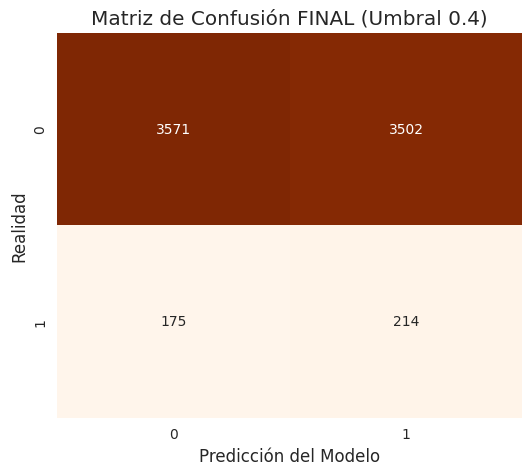


Conclusión: Con el umbral al 0.4, el sistema detecta 214 de los 389 accidentes graves.
Mejora de Recall: 55.0% (vs 35% inicial).


In [5]:
y_probas_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

umbral_decision = 0.40

print(f"\nAplicando nuevo umbral de decisión: {umbral_decision*100}%")

preds_optimizadas_xgb = (y_probas_xgb >= umbral_decision).astype(int)

print(classification_report(y_test, preds_optimizadas_xgb, target_names=['Leve', 'Grave']))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, preds_optimizadas_xgb), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title(f'Matriz de Confusión FINAL (Umbral {umbral_decision})')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

tp = confusion_matrix(y_test, preds_optimizadas_xgb)[1, 1]
total_graves = sum(y_test)
print(f"\nConclusión: Con el umbral al {umbral_decision}, el sistema detecta {tp} de los {total_graves} accidentes graves.")
print(f"Mejora de Recall: {tp/total_graves:.1%} (vs 35% inicial).")

### 4.5. Validación de la decisión

Tras establecer el umbral en 0.40 basándonos en números, es fundamental validar esta decisión visualmente. Para ello, utilizamos la curva de precisión-recall.

Este gráfico nos permitirá ver la "batalla" entre:
* **Línea Verde (Recall):** Nuestra capacidad para detectar accidentes graves. Queremos que esté lo más alta posible.
* **Línea Azul (Precisión):** La fiabilidad de nuestras alertas.

Buscamos el momento exacto antes de que la capacidad de detección del modelo (línea verde) se desplome.

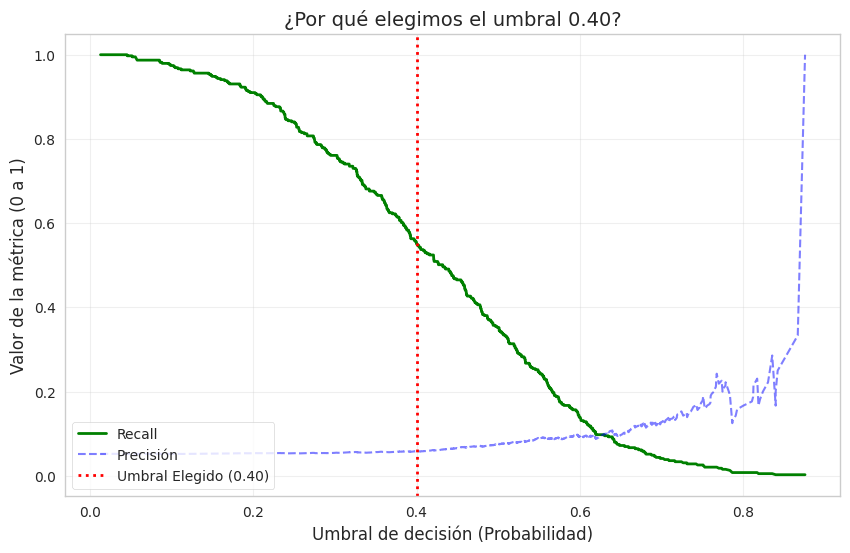

In [6]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probas_xgb)

plt.figure(figsize=(10, 6))

plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisión', alpha=0.5)

plt.axvline(x=0.40, color='red', linestyle=':', linewidth=2, label='Umbral Elegido (0.40)')

plt.title('¿Por qué elegimos el umbral 0.40?', fontsize=14)
plt.xlabel('Umbral de decisión (Probabilidad)', fontsize=12)
plt.ylabel('Valor de la métrica (0 a 1)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.show()

### 4.6. Interpretación de la Curva

El gráfico confirma que 0.40 es óptimo para este modelo:

1.  **Estabilidad inicial:** Vemos que la línea verde (recall) se mantiene alta y estable en la zona izquierda del gráfico. Esto significa que el modelo tiene mucha seguridad en los casos más obvios.
2.  **La bajada":** Justo al cruzar la línea roja (umbral 0.40), la línea verde comienza a descender con una pendiente más pronunciada.
    * Significado: Si intentáramos ser más exigentes (subiendo el umbral a 0.50 o 0.60), la capacidad de detección del sistema colapsaría.
3.  **Conclusión visual:** La línea roja marca el último punto donde maximizamos la detección de peligros sin destruir completamente la precisión.
---

# 5. Modelo B: Predicción de alcoholemia

### 5.1. Cambio de enfoque: 
Mientras que el Modelo A intentaba predecir la gravedad del accidente, el Modelo B se centra en predecir el comportamiento humano.

**Hipótesis:**
A diferencia de la gravedad, que depende de mil factores mecánicos, el consumo de alcohol al volante no es aleatorio: sigue patrones sociales, temporales y geográficos muy marcados (fines de semana, zonas de ocio nocturno, madrugadas).
Por tanto, espero que las variables `hora`, `fecha` y `ubicación` tengan más importancia en este caso.

### 5.2. Objetivo
* **Target:** `target_alcohol` (1 = Positivo en alcoholemia).
* **Algoritmo:** XGBoost
* **Valor para el negocio:**
    * **Actual:** Controles aleatorios o basados en la intuición.
    * **Propuesta:** Optimización de controles de alcolemia. Si el modelo predice alta probabilidad de alcohol en el X sitio los sábados a las 03:00, enviar una patrulla allí maximiza la probabilidad de interceptar conductores alcoholizados antes de que ocurra un accidente.

Ratio de desbalance Alcohol: 33.62

Informe de clasificación
              precision    recall  f1-score   support

    Negativo       0.98      0.85      0.91      7246
    Positivo       0.10      0.53      0.17       216

    accuracy                           0.84      7462
   macro avg       0.54      0.69      0.54      7462
weighted avg       0.96      0.84      0.89      7462



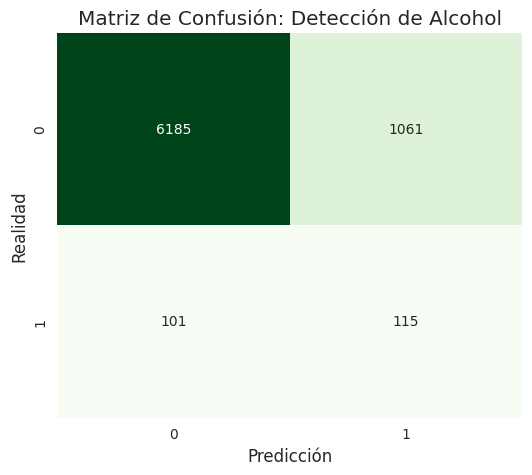

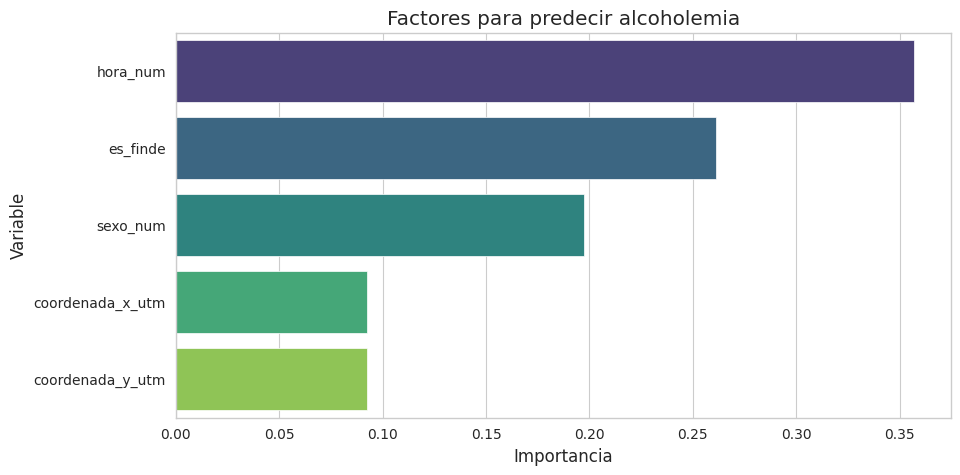

In [7]:
features_alcohol = ['hora_num', 'sexo_num', 'es_finde', 'coordenada_x_utm', 'coordenada_y_utm']

X_b = df_clean[features_alcohol]
y_b = df_clean['target_alcohol'] # Objetivo: 1=Positivo, 0=Negativo

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_b
)

ratio_b = (y_train_b == 0).sum() / (y_train_b == 1).sum()
print(f"Ratio de desbalance Alcohol: {ratio_b:.2f}")

modelo_alcohol = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio_b,
    random_state=42,
    eval_metric='logloss'
)

modelo_alcohol.fit(X_train_b, y_train_b)

predicciones_b = modelo_alcohol.predict(X_test_b)

print("\nInforme de clasificación")
print(classification_report(y_test_b, predicciones_b, target_names=['Negativo', 'Positivo']))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_b, predicciones_b), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión: Detección de Alcohol')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

importancia_b = pd.DataFrame({
    'Variable': features_alcohol,
    'Peso': modelo_alcohol.feature_importances_
}).sort_values('Peso', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Peso', y='Variable', data=importancia_b, palette='viridis', hue='Variable',legend=False)
plt.title('Factores para predecir alcoholemia')
plt.xlabel('Importancia')
plt.show()

### 5.3. Interpretación  del modelo

**Análisis de la matriz de confusión:**
* **Capacidad de detección:** El modelo detecta el 53% de los casos positivos reales (115 de 216).
* **Precision:** La precisión es del 10% (1 acierto por cada 10 alertas).

**¿Por qué un 10% de precisión es un éxito?**
En un control de alcoholemia aleatorio estándar (sin inteligencia artificial), la tasa de positivos suele ser muy baja (entorno al 1-2% (Dato de la DGT 1.2%)).
* **Sin Modelo:** La policía detiene 100 coches al azar -> Encuentra 1 o 2 positivos.
* **Con Modelo:** La policía detiene 100 coches sugeridos por el modelo -> Encuentra 10 positivos.

**Conclusión:** El modelo actúa como un multiplicador de eficiencia (x5). No elimina el trabajo policial, pero dirige los recursos a las franjas horarias y zonas donde la probabilidad de acierto es cinco veces mayor que el azar.

---



### 5.4. Explicabilidad avanzada (XAI)

Hasta este punto, sabemos que el modelo funciona (tiene buenas métricas) y sabemos qué variables son importantes, pero ¿Por qué el modelo dice que X conductor es riesgoso?

Para resolver esto, usaré SHAP (SHapley Additive exPlanations).
Esta técnica no solo nos dice qué variables importan, sino cómo importan:
* ¿La hora alta suma o resta riesgo?
* ¿Ser fin de semana aumenta o disminuye la probabilidad?

**Objetivo:** Validar que el modelo ha aprendido patrones lógicos (p.ej., madrugada = peligro).

Calculando SHAP


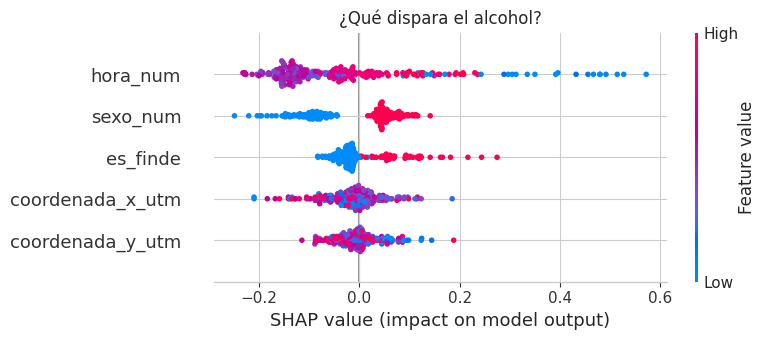

In [8]:
import shap
import matplotlib.pyplot as plt

# Uso de un "masker" para decirle a SHAP cómo rellenar los huecos cuando oculta datos
masker = shap.maskers.Independent(data=X_test_b)

# predict_proba devuelve 2 columnas (prob no alcohol, prob alcohol).
# Utilizo la columna [:,1] para explicar solo la probabilidad de positivo en alcohol
def f_wrapper(X):
    return modelo_alcohol.predict_proba(X)[:, 1]

print("Calculando SHAP")
explainer = shap.Explainer(f_wrapper, masker)

# Como es lento, solo voy a poner 250
shap_values = explainer(X_test_b.iloc[:250])

# Visualización en gráfico beeswarm
plt.figure()
plt.title("¿Qué dispara el alcohol?", fontsize=12)
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

### 5.5. Interpretación de los Valores SHAP

El gráfico beeswarm confirma visualmente la lógica del modelo. Cada punto es un accidente del set de prueba:

1.  **Variable `hora_num`:**
    * Observamos puntos rojos (horas altas / madrugada) extendiéndose hacia la derecha, aunque también hay algun que otro azul.
    * **Interpretación:** A medida que avanza la noche, el modelo aumenta la probabilidad de predicción de alcohol. 

2.  **Variable `sexo_num`:**
    * Existe una separación clara. Los puntos rojos (valor 1, hombres) empujan el riesgo hacia la derecha (mayor probabilidad).
    * Esto indica que el modelo ha detectado una mayor incidencia estadística de positivos en los hombres.

3.  **Variable `es_finde`:**
    * Los puntos rojos (es fin de semana) se sitúan a la derecha del eje central, sumando probabilidad de alcohol.
    * Los puntos azules (días laborables) están a la izquierda, restando probabilidad.

**Conclusión del modelo B:**
Las decisiones del modelo se relacionan perfectamente con la intuición policial: el riesgo sube por la combinación de madrugada, fin de semana y perfil del conductor. Esto hace del modelo una buena herramiento de apoyo para la toma de decisiones en controles de alcoholemia.




### 5.6. Validación Visual

El análisis de importancia de variables (punto anterior) ha sido claro: `hora_num` es de las variables más importantes del modelo. Sin embargo, saber que "la hora importa" no es suficiente para la policía, necesitamos saber exactamente cuándo se dispara el riesgo.

En este gráfico veremos la probabilidad de alcoholemia hora a hora.

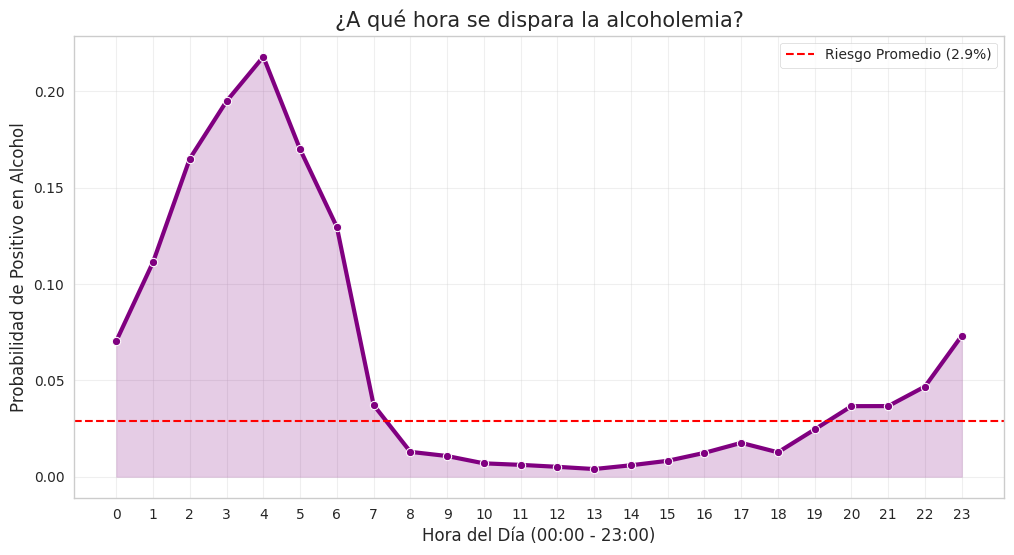

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt

# Agrupamos por hora para ver la tasa media de positivos
# Esto dice: de todos los accidentes a X hora, qué % fueron por alcohol???
riesgo_hora = df_clean.groupby('hora_num')['target_alcohol'].mean().reset_index()

# Visualización
plt.figure(figsize=(12, 6))

sns.lineplot(data=riesgo_hora, x='hora_num', y='target_alcohol', marker='o', color='purple', linewidth=3)

# Promedio global
promedio_alcohol = df_clean['target_alcohol'].mean()
plt.axhline(y=promedio_alcohol, color='r', linestyle='--', label=f'Riesgo Promedio ({promedio_alcohol*100:.1f}%)')

plt.title('¿A qué hora se dispara la alcoholemia?', fontsize=15)
plt.xlabel('Hora del Día (00:00 - 23:00)', fontsize=12)
plt.ylabel('Probabilidad de Positivo en Alcohol', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24)) # Mostrar todas las horas
plt.fill_between(riesgo_hora['hora_num'], riesgo_hora['target_alcohol'], alpha=0.2, color='purple')
plt.legend()

plt.show()

### 5.7. Interpretación:

**Análisis 24h:**
Claramente se ve un patrón:

1.  **08:00 - 19:00:** La probabilidad de alcoholemia es residual (cercana al 0%). Realizar controles en estas horas es ineficiente.
2.  **Noche:** A partir de las 22:00, hasta las 8:00, el riesgo sube muchísimo.
3.  **04:00 AM:** Se alcanza el máximo riesgo, superando el 20% de probabilidad. En este momento, 1 de cada 5 accidentes está relacionado con el alcohol.

**Conclusión:**
El modelo sugiere concentrar el 80% de los recursos de control de alcoholemia entre las 00 y las 6.

---
# 6. Modelo C: Detección de "Puntos Negros"

### 6.1. Cambio de estrategia: de "que" a "donde"
Hasta ahora, he utilizado aprendizaje supervisado (modelos A y B) para predecir gravedad o alcohol. En esta fase aplicare aprendizaje no supervisado.
Ya no hay que darle al modelo la respuesta correcta, si no coordenadas y que agrupe los datos por proximidad.

### 6.2. El problema
Tradicionalmente, los ayuntamientos analizan la siniestralidad por barrios. Esto tiene un fallo: los accidentes no se relacionan por barrios ni zonas.
* Ejemplo: Una intersección peligrosa puede estar justo en el límite entre dos barrios, dividiendo sus estadísticas y ocultando el problema real.

### 6.3. La solución: K-Means clustering
Usaré el algoritmo **K-Means** para generar K zonas basada exclusivamente en la densidad de los accidentes.
* **Objetivo:** Identificar clústeres.
* **Utilidad:** Estas zonas permitirán detectar cruces específicos que requieren intervención (mejor iluminación, rotondas, badenes), independientemente del barrio al que pertenezcan.

Calculando topología de la siniestralidad (puede tardar unos segundos)...


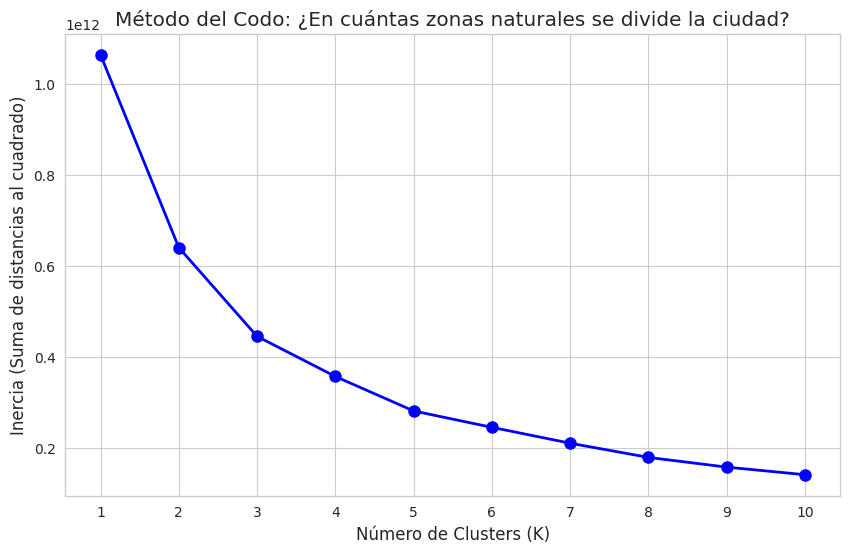

In [10]:
# Decidir K

# Preparar los datos (Solo coordenadas X e Y)
# El algoritmo solo mira la ubicación física
X_geo = df_clean[['coordenada_x_utm', 'coordenada_y_utm']]

# Calcular la inercia para k=1 hasta k=10
inertia = []
K_range = range(1, 11)

print("Calculando topología de la siniestralidad (puede tardar unos segundos)...")

for k in K_range:
    # Entrenar K-Means para cada número de clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_geo)
    inertia.append(kmeans.inertia_)

# Grafica del resultado
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2)
plt.title('Método del Codo: ¿En cuántas zonas naturales se divide la ciudad?')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

### 6.4. Elección de K

**Interpretación del gráfico:**
Hay una caída de la inercia hasta K=3, donde la curva se estabilizaa. Sin embargo, para poder distinguir entre diferentes barrios o zonas, cogeré K=5.

Esto dividirá la ciudad en 5 grandes zonas, pudiendo identificar si los accidentes se concentran en el centro histórico, en las salidas, o en polígonos industriales.

Generando mapa de calor para 5 zonas


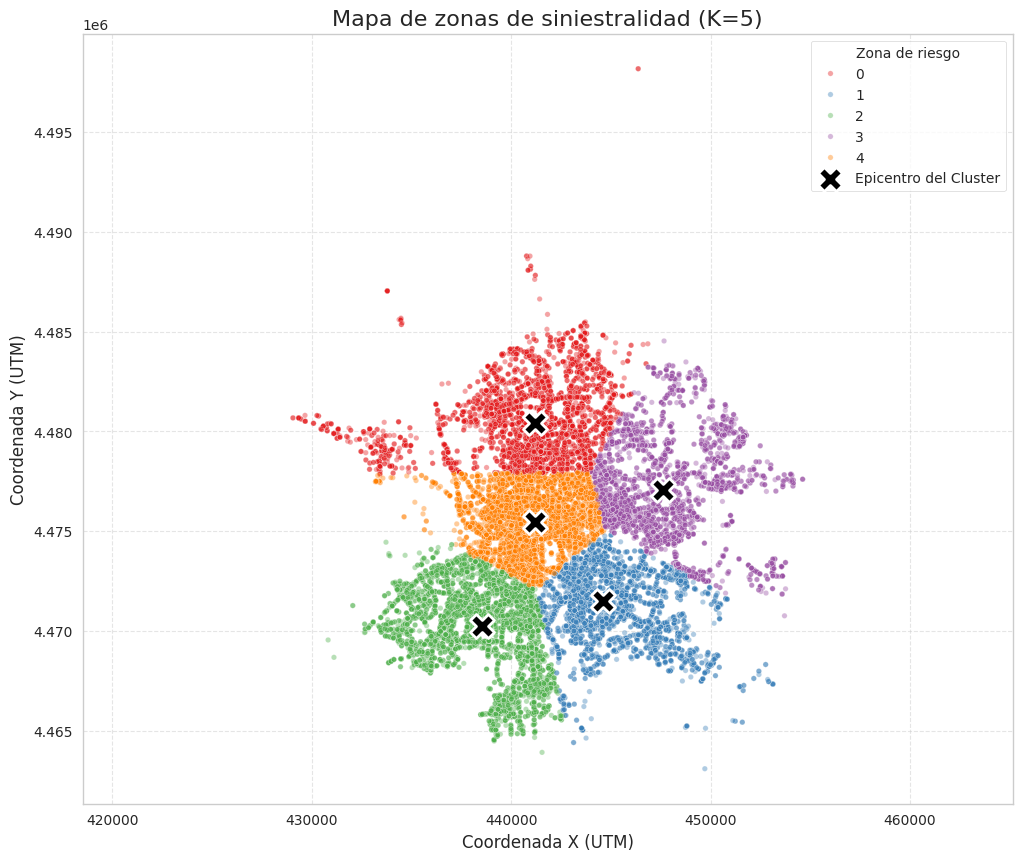


Ranking de volumen de accidentes)
   Zona ID  Total Accidentes  % del Total
0        4             10950         29.4
1        2              7941         21.3
2        1              7077         19.0
3        0              6644         17.8
4        3              4694         12.6


In [11]:
k_optimo = 5

print(f"Generando mapa de calor para {k_optimo} zonas")

# Entrenar el modelo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
# Guardo la etiqueta del cluster en el dataframe original para saber a qué zona pertenece cada accidente
df_clean['cluster_zona'] = kmeans_final.fit_predict(X_geo)

plt.figure(figsize=(12, 10))

# Pintar accidentes 
sns.scatterplot(
    data=df_clean, 
    x='coordenada_x_utm', 
    y='coordenada_y_utm', 
    hue='cluster_zona', 
    palette='Set1',   
    s=15,             
    alpha=0.4,        
    legend='full'
)

# Centros de gravedad
centers = kmeans_final.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1], 
    c='black', s=300, marker='X', 
    label='Epicentro del Cluster', 
    edgecolor='white', linewidth=2
)

# Decoración
plt.title(f'Mapa de zonas de siniestralidad (K={k_optimo})', fontsize=16)
plt.xlabel('Coordenada X (UTM)')
plt.ylabel('Coordenada Y (UTM)')
plt.legend(title='Zona de riesgo')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Análisis de peligrosidad por zona
print("\nRanking de volumen de accidentes)")
conteo = df_clean['cluster_zona'].value_counts().reset_index()
conteo.columns = ['Zona ID', 'Total Accidentes']
conteo['% del Total'] = (conteo['Total Accidentes'] / len(df_clean) * 100).round(1)
print(conteo)

### 6.5. Visualización en el mapa

Para validar si las zonas generadas por K-Means tienen sentido, voy a intentar visualizar la extensión real de cada clúster en un mapa.

**Herramientas:**

1.  **Folium:**
    * Uso folium para generar un mapa interactivo (basado en Leaflet.js y OpenStreetMap).
    * A diferencia de los mapas estáticos, como por ejemplo el de matplotlib, folium permite hacer zoom y explorar el mapa: ver si una zona roja corresponde a una calle, un polígono industrial o cualquier zona específica.

2.  **Transformación de coordenadas (UTM a GPS):**
    * Los datos originales están en UTM.
    * Los mapas interactivos funcionan con latitud/longitud (GPS).
    * Utilizaré pyproj para cambiar el formato.

3.  **Optimización de rendimiento (sampling):**
    * Dibujar miles de puntos a la vez consume mucha memoria del navegador y puede congelar la visualización (me ha pasado y no es agradable).
    * **Solución:** Coger una muestra representativa de 1.500 accidentes. Esto es suficiente para visualizar la densidad y las fronteras de cada zona.

In [12]:
import folium
from pyproj import Transformer

# Configuración de conversión
transformer = Transformer.from_crs("epsg:25830", "epsg:4326")

def convertir_coords_simple(x, y):
    return transformer.transform(x, y)

# Solo pongo 1500 porque con un número más alto peta todo
df_mapa = df_clean.sample(n=1500, random_state=42).copy()

# Convertir coordenadas
lat_lon = df_mapa.apply(
    lambda row: convertir_coords_simple(row['coordenada_x_utm'], row['coordenada_y_utm']), 
    axis=1
)
df_mapa['lat'] = [x[0] for x in lat_lon]
df_mapa['lon'] = [x[1] for x in lat_lon]

# Centro del mapa
centro_lat = df_mapa['lat'].mean()
centro_lon = df_mapa['lon'].mean()

# Mapa Base
mapa_zonas = folium.Map(location=[centro_lat, centro_lon], zoom_start=12, tiles='OpenStreetMap')

colores_zona = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange'}

print("Pintando nube de puntos")

for idx, row in df_mapa.iterrows():
    cluster_id = row['cluster_zona']
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3, 
        color=colores_zona[cluster_id],
        fill=True,
        fill_color=colores_zona[cluster_id],
        fill_opacity=0.6,
    ).add_to(mapa_zonas)

# Epicientros
centros_utm = pd.DataFrame(kmeans_final.cluster_centers_, columns=['coordenada_x_utm', 'coordenada_y_utm'])
centros_gps = centros_utm.apply(lambda row: convertir_coords_simple(row['coordenada_x_utm'], row['coordenada_y_utm']), axis=1)

for i, coords in enumerate(centros_gps):
    folium.Marker(
        location=[coords[0], coords[1]],
        icon=folium.Icon(color='black', icon='star', prefix='fa'),
        popup=f"<b>CENTRO ZONA {i}</b>"
    ).add_to(mapa_zonas)

print("Mapa generado.")
mapa_zonas

Pintando nube de puntos
Mapa generado.


# 7. Conclusión

En este proyecto he analizado los datos de accidentes de madrid para buscar patrones que permitan salvar vidas, no solo describir lo que ya ha pasado.

Estos son los tres resultados principales que he conseguido:

### 1. Gestión sanitaria (Modelo de gravedad)
El principal problema era que habían muy pocos datos de accidentes graves frente a los leves, lo que confundía al modelo. He solucionado esto ajustando el umbral.
* **Resultado:** Ahora detecta el 55% de los accidentes graves.
* **Utilidad:** Esto sirve para que las ambulancias se posicionen mejor en las zonas de riesgo calculadas, ganando tiempo.

### 2. Eficiencia policial (Modelo de alcoholemia)
No bastaba con predecir el alcohol, quería entender por qué ocurre. Usando gráficos SHAP, he comprobado que la hora, y el día de la semana (fines de semana), son factores importantes.
* **Resultado:** He identificado una franja horaria, de 00:00 a 06:00 de la mañana, donde el riesgo de dar positivo se multiplica por 7.
* **Utilidad:** Si la policía concentra sus controles en esa franja y en los fines de semana, será 5 veces más efectiva que patrullando al azar.

### 3. Puntos con más accidentes (El mapa)
En lugar de usar los mapas de distritos oficiales, he dejado que el algoritmo K-Means agrupe los accidentes por cercanía.
* **Resultado:** El mapa interactivo muestra 5 zonas de riesgo que no coinciden necesariamente con los barrios.
* **Utilidad:** He localizado las coordenadas exactas donde se acumulan los choques. El Ayuntamiento debería revisar la iluminación o la señalización en esos puntos.


**Resumen:**
Con este trabajo he demostrado que, usando los datos correctamente, se puede pasar de reaccionar a los accidentes a poder
prevenirlos.

---

# 8. Bibliografía y referencias

Para el desarrollo técnico de este proyecto he consultado las fuentes originales y la documentación oficial de las siguientes tecnologías:

### 1. Modelado (XGBoost)
He seleccionado este algoritmo por su eficiencia y manejo de valores nulos, basándome en su publicación original:
* **Paper Original:** *Chen, T., & Guestrin, C. (2016).* "XGBoost: A Scalable Tree Boosting System". Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
* **Fundamento Teórico:** Gradient Boosting Machines (GBM), propuesto originalmente por *Jerome H. Friedman (2001)* en "Greedy Function Approximation: A Gradient Boosting Machine".

### 2. Explicabilidad (SHAP)
Para la interpretación del modelo de alcoholemia he recurrido a la teoría de juegos cooperativos, aplicando los valores de Shapley:
* **Paper Original:** *Lundberg, S. M., & Lee, S. I. (2017).* "A Unified Approach to Interpreting Model Predictions". Advances in Neural Information Processing Systems 30 (NIPS 2017).
* **Teoría Base:** *Shapley, L. S. (1953).* "A Value for n-Person Games". Contributions to the Theory of Games (Princeton University Press).

### 3. Clustering (K-Means)
Para la detección de puntos negros he utilizado el algoritmo de Lloyd, estandarizado posteriormente como K-Means:
* **Algoritmo:** *Lloyd, S. (1982).* "Least squares quantization in PCM". IEEE Transactions on Information Theory.
* **Definición del término:** *MacQueen, J. (1967).* "Some methods for classification and analysis of multivariate observations".

### 4. Visualización espacial (Folium & Leaflet)
* **Documentación Oficial de Folium (v0.14.0):** Python wrapper for Leaflet.js. [https://python-visualization.github.io/folium/](https://python-visualization.github.io/folium/)
* **Leaflet.js:** Biblioteca de JavaScript de código abierto para mapas interactivos móviles.

---


# 9. Próximos pasos y mejoras para el futuro

Aunque el proyecto cumple con los objetivos iniciales, si tuviera la oportunidad de continuar desarrollándolo, estas serían mis prioridades para mejorarlo:

### 1. Más datos (Meteorología y tráfico)
Actualmente el modelo no sabe si llueve o hay niebla.
* **Mejora:** Cruzar mis datos con la metereología.
* **Hipótesis:** Estoy casi seguro de que la lluvia es un factor multiplicador de la gravedad, y añadirla mejoraría la precisión del Modelo A.

### 2. De analizar el pasado a predecir tendencias
Ahora mismo trato cada accidente como un evento aislado.
* **Mejora:** Implementar modelos de series temporales (como **Prophet** o **LSTM**).
* **Objetivo:** Poder llegar a predecir nuevas tendencias, en vez de analizar solo cosas del pasado.

### 3. Pasar a la realidad (app para la policía)
Un Notebook no es útil para un agente en la calle.
* **Mejora:** Crear una pequeña aplicación web usando, por ejemplo, Streamlit.
* **Visión:** Que el policía pueda ver en su tablet el mapa de calor en tiempo real y recibir alertas del tipo: "Atención: Alta probabilidad de alcoholemia en tu zona durante las próximas 2 horas".